# CMAPSS Data Preprocessing Pipeline for RUL Prediction

This notebook prepares the NASA CMAPSS turbofan engine dataset for Remaining Useful Life (RUL) prediction.

The pipeline includes:
- Data loading
- Sensor selection
- RUL labeling (train & test)
- Normalization
- Sequence (window) generation

The output is model-ready tensors suitable for deep learning models such as LSTM and TCN.

## 1. Environment Setup

We begin by importing required libraries and fixing random seeds to ensure reproducibility.

In [46]:
import pandas as pd
import numpy as np
import torch
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

## 2. Load CMAPSS Dataset

The CMAPSS dataset consists of multivariate time-series sensor readings from turbofan engines.

Each row represents a single operational cycle of an engine unit.

Columns include:
- Unit ID
- Cycle number
- Operational settings (op_1, op_2, op_3)
- Sensor measurements (s_1 to s_21)

In [47]:
def load_cmapss(path):
    cols = ['unit_id', 'cycle'] + \
           [f'op_{i}' for i in range(1,4)] + \
           [f's_{i}' for i in range(1,22)]
    
    df = pd.read_csv(path, sep=r'\s+', header=None)
    df.columns = cols
    return df

train = load_cmapss("/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/train_FD001.txt")
test = load_cmapss("/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/test_FD001.txt")

rul_test = pd.read_csv("/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/RUL_FD001.txt", header=None)
rul_test.columns = ['RUL']

## 3. Sensor Selection

The CMAPSS dataset contains 21 sensor measurements; however, not all sensors are informative for degradation modeling.

Following standard preprocessing practices in prior work (e.g., Saxena & Goebel, 2008 and subsequent studies), we retain a subset of sensors that exhibit meaningful degradation trends.

Selected sensors:
[2, 3, 4, 7, 8, 9, 11, 12, 13, 14, 15, 17, 20, 21]

These sensors are known to:
- Show noticeable variation over time
- Correlate with engine degradation
- Avoid near-constant or noisy signals

Using this subset reduces noise and improves model performance.

In [48]:
selected_sensors = [2,3,4,7,8,9,11,12,13,14,15,17,20,21]
sensor_cols = [f's_{i}' for i in selected_sensors]

def select_sensors(df):
    return df[['unit_id', 'cycle'] + sensor_cols]

train = select_sensors(train)
test = select_sensors(test)

print(train.shape)

(20631, 16)


## 4. RUL Labeling (Training Data)

For training data, the Remaining Useful Life (RUL) is computed as:

RUL = max_cycle - current_cycle

To stabilize learning, RUL is capped at 125 cycles:
- Prevents dominance of early-cycle samples
- Encourages focus on degradation phase

In [49]:
def label_rul(df, max_rul=125):
    max_cycle = df.groupby('unit_id')['cycle'].max().reset_index()
    max_cycle.columns = ['unit_id', 'max_cycle']
    df = df.merge(max_cycle, on='unit_id')
    df['RUL'] = df['max_cycle'] - df['cycle']
    df['RUL'] = df['RUL'].clip(upper=max_rul)
    return df.drop(columns=['max_cycle'])

train = label_rul(train)

print(train[['unit_id','cycle','RUL']].head())

   unit_id  cycle  RUL
0        1      1  125
1        1      2  125
2        1      3  125
3        1      4  125
4        1      5  125


## 5. RUL Labeling (Test Data)

Unlike training data, test data does not include full failure trajectories.

We use the provided RUL file to compute:

RUL = (last_observed_cycle + provided_RUL) - current_cycle

This reconstructs the full degradation timeline for each test unit.

RUL is also capped at 125 for consistency.

In [51]:
def label_test_rul(test_df, rul_df, max_rul=125):
    max_cycle = test_df.groupby('unit_id')['cycle'].max().reset_index()
    max_cycle.columns = ['unit_id', 'max_cycle']
    
    rul_df['unit_id'] = rul_df.index + 1
    
    test_df = test_df.merge(max_cycle, on='unit_id')
    test_df = test_df.merge(rul_df, on='unit_id')
    
    test_df['RUL'] = test_df['max_cycle'] + test_df['RUL'] - test_df['cycle']
    test_df['RUL'] = test_df['RUL'].clip(upper=max_rul)
    
    return test_df.drop(columns=['max_cycle'])

test = label_test_rul(test, rul_test)

print(test[['unit_id','cycle','RUL']].head())

   unit_id  cycle  RUL
0        1      1  125
1        1      2  125
2        1      3  125
3        1      4  125
4        1      5  125


## 6. Feature Normalization

Sensor values are normalized using Min-Max scaling:

- Fit on training data only
- Applied to both train and test data

This ensures:
- Stable training
- No data leakage from test set

In [53]:
from sklearn.preprocessing import MinMaxScaler

def normalize(train_df, test_df, sensor_cols):
    scaler = MinMaxScaler()
    
    train_df[sensor_cols] = scaler.fit_transform(train_df[sensor_cols])
    test_df[sensor_cols] = scaler.transform(test_df[sensor_cols])
    
    return train_df, test_df, scaler

train, test, scaler = normalize(train, test, sensor_cols)

## 7. Sequence (Sliding Window) Generation

Time-series data is converted into fixed-length sequences.

Window size: 30 cycles

Each sample consists of:
- Input: 30 consecutive timesteps of sensor data
- Target: RUL at the final timestep

Output shape:
(samples, timesteps, features)

This format is required for sequence models like LSTM and TCN.

In [55]:
import numpy as np

def create_sequences(df, sensor_cols, window_size=30):
    sequences = []
    labels = []
    
    for unit in df['unit_id'].unique():
        unit_df = df[df['unit_id'] == unit]
        
        data = unit_df[sensor_cols].values
        rul = unit_df['RUL'].values
        
        for i in range(len(unit_df) - window_size + 1):
            sequences.append(data[i:i+window_size])
            labels.append(rul[i+window_size-1])
    
    return np.array(sequences), np.array(labels)

## 8. Data Integrity Checks

We verify:
- No missing values
- Correct tensor shapes
- Consistency between train and test data

This step ensures the pipeline is reliable before modeling.

In [56]:
X_train, y_train = create_sequences(train, sensor_cols)
X_test, y_test = create_sequences(test, sensor_cols)

print(X_train.shape)
print(y_train.shape)

(17731, 30, 14)
(17731,)


## 9. RUL Distribution Analysis

We visualize the distribution of RUL values.

Observation:
- Large concentration at RUL = 125 (due to capping)
- Fewer samples in low RUL (failure region)

Implication:
- Dataset is imbalanced
- Models may struggle to predict near failure

This motivates:
- Weighted loss functions
- Physics-based data augmentation (future work)

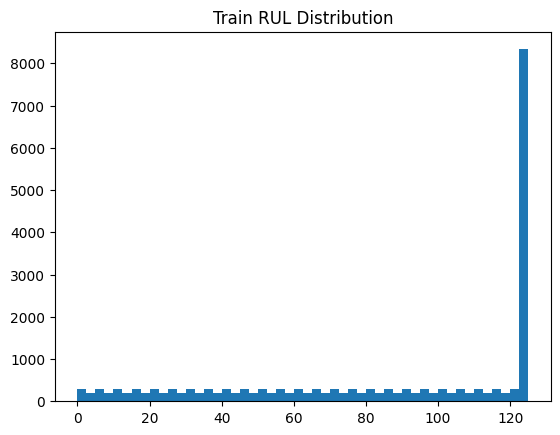

In [58]:
import matplotlib.pyplot as plt

plt.hist(train['RUL'], bins=50)
plt.title("Train RUL Distribution")
plt.show()

## 10. Final Output

The preprocessing pipeline outputs:

- X_train: (N, 30, 14)
- y_train: (N,)
- X_test: (M, 30, 14)
- y_test: (M,)

These tensors are ready for model training.

## 11. Notes for Future Work

This preprocessing pipeline serves as the foundation for:

- Temporal Convolutional Networks (TCN)
- Federated Learning across non-IID clients
- Physics-based degradation simulation
- Uncertainty-aware RUL prediction

Further enhancements will focus on handling data imbalance and improving generalization across operating conditions.